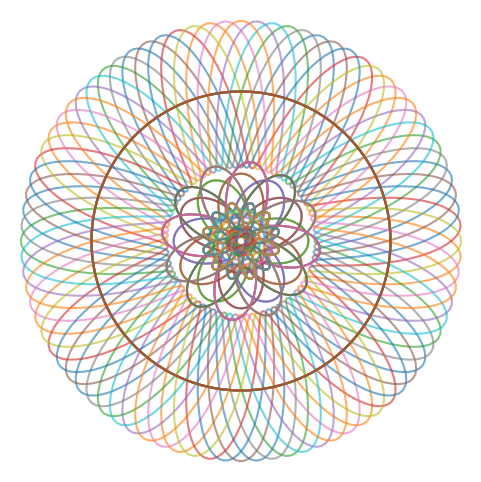

In [212]:
# --- Create a 3-qubit quantum circuit with basic entanglement ---
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(np.pi / 4, 1)
qc.rx(np.pi / 3, 2)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()

# --- Run the circuit on QASM simulator ---
# Execution
simulator = Aer.get_backend('qasm_simulator')
qc_transpiled = transpile(qc, simulator)
result = simulator.run(qc_transpiled, backend=simulator, shots=1024).result()
counts = result.get_counts()

# --- Artistic pattern generation ---
num_symmetry = 12 # Number of radial repetitions
theta = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Map each quantum state to a flower-like petal
for bitstring, freq in counts.items():
    norm_freq = freq / 1024
    index = int(bitstring, 2)
    angle_offset = (index % num_symmetry) * (2 * np.pi / num_symmetry)

    # Define a radius pattern modulated by frequency and state value
    r = norm_freq * (1 + 0.5 * np.sin(index * theta))

    for i in range(num_symmetry):
        rotation = angle_offset + i * (2 * np.pi / num_symmetry)
        ax.plot(theta + rotation, r, alpha=0.6, linewidth=1.5)

# Save the resulting image
plt.savefig("quantum_mandala.png", dpi=300, bbox_inches='tight')
plt.show()
